In [1]:
# Import libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
# Create dataset
data = {
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temp": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
             "Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity": ["High","High","High","High","Normal","Normal","Normal",
                 "High","Normal","Normal","Normal","High","Normal","High"],
    "Wind": ["Weak","Strong","Weak","Weak","Weak","Strong","Strong",
             "Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "PlayTennis": ["No","No","Yes","Yes","Yes","No","Yes",
                   "No","Yes","Yes","Yes","Yes","Yes","No"]
}

df = pd.DataFrame(data)

In [3]:
# Encode categorical variables
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [4]:
# Features and target
X = df.drop("PlayTennis", axis=1)
y = df["PlayTennis"]

In [5]:
# Train ID3-like Decision Tree (entropy criterion)
model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X, y)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [6]:
# Predict example
sample = pd.DataFrame({
    "Outlook": [label_encoders["Outlook"].transform(["Sunny"])[0]],
    "Temp": [label_encoders["Temp"].transform(["Cool"])[0]],
    "Humidity": [label_encoders["Humidity"].transform(["High"])[0]],
    "Wind": [label_encoders["Wind"].transform(["Strong"])[0]]
})

In [7]:
prediction = model.predict(sample)
print("Prediction (PlayTennis):",
      label_encoders["PlayTennis"].inverse_transform(prediction)[0])

Prediction (PlayTennis): No


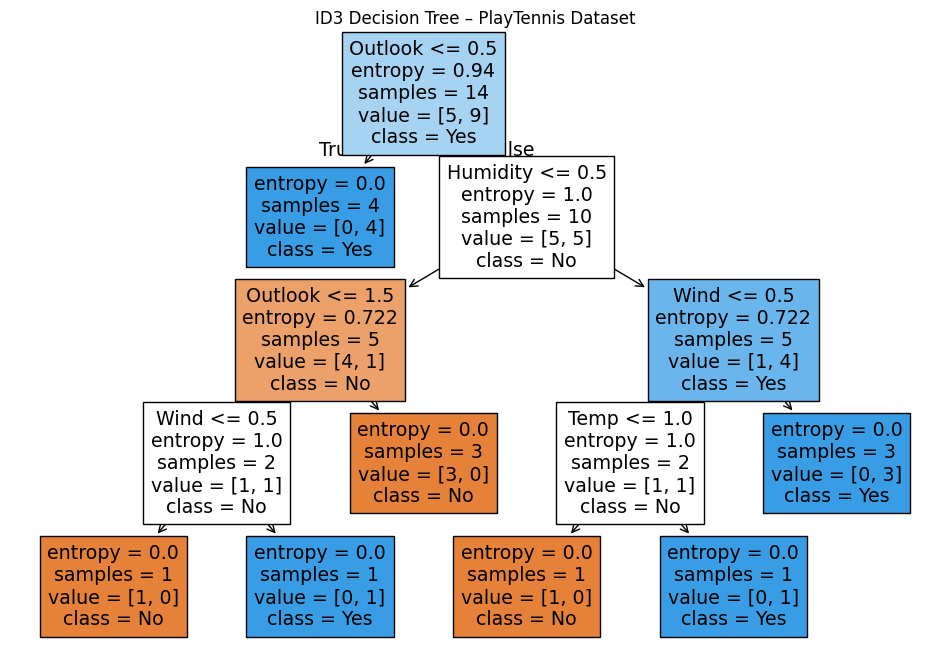

In [8]:
# Plot tree
plt.figure(figsize=(12,8))
plot_tree(model,
          feature_names=X.columns,
          class_names=label_encoders["PlayTennis"].classes_,
          filled=True)
plt.title("ID3 Decision Tree – PlayTennis Dataset")
plt.show()

In [9]:
# Step 1: Import libraries
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [10]:
data = {
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temp": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
             "Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity": ["High","High","High","High","Normal","Normal","Normal",
                 "High","Normal","Normal","Normal","High","Normal","High"],
    "Wind": ["Weak","Strong","Weak","Weak","Weak","Strong","Strong",
             "Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "Golf Players": [25,30,46,45,52,23,43,35,38,46,48,52,44,30]
}

In [11]:
df = pd.DataFrame(data)

In [12]:
# Step 3: Encode categorical features
label_encoders = {}
for column in ["Outlook", "Temp", "Humidity", "Wind"]:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [13]:
# Step 4: Split features and target
X = df[["Outlook", "Temp", "Humidity", "Wind"]]
y = df["Golf Players"]

In [14]:
# Step 5: Train Decision Tree Regressor
model = DecisionTreeRegressor(random_state=42)
model.fit(X, y)

DecisionTreeRegressor(random_state=42)

In [15]:
# Step 6: Predict for a new sample
# Example: Outlook=Rain, Temp=Mild, Humidity=Normal, Wind=Weak
new_sample = pd.DataFrame({
    "Outlook": [label_encoders["Outlook"].transform(["Rain"])[0]],
    "Temp": [label_encoders["Temp"].transform(["Mild"])[0]],
    "Humidity": [label_encoders["Humidity"].transform(["Normal"])[0]],
    "Wind": [label_encoders["Wind"].transform(["Weak"])[0]]
})

In [16]:
prediction = model.predict(new_sample)
print("Predicted number of Golf Players:", prediction[0])

Predicted number of Golf Players: 46.0


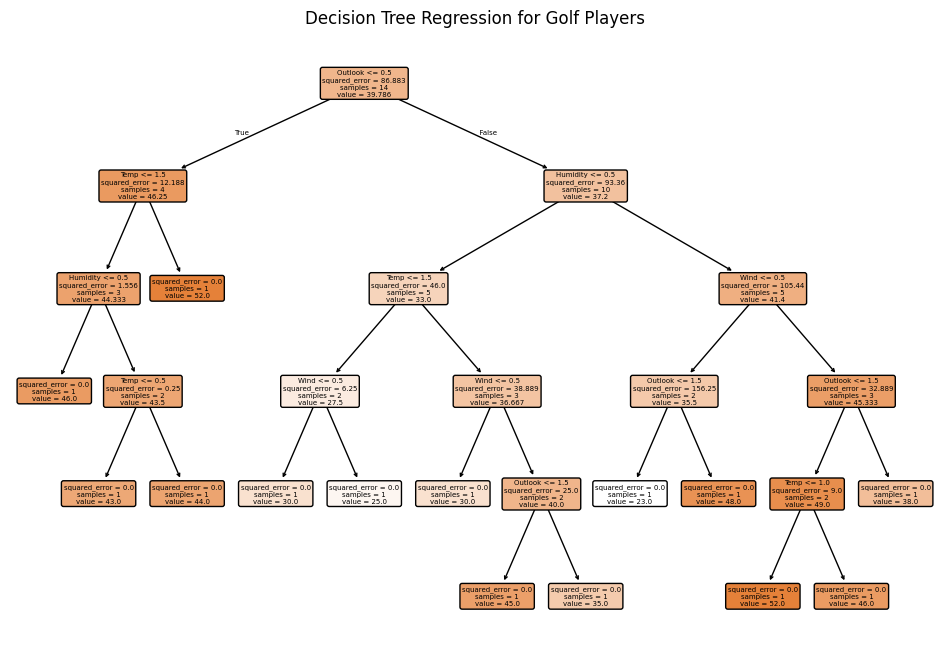

In [17]:
# Step 7: Visualize the decision tree
plt.figure(figsize=(12, 8))
plot_tree(model,
          feature_names=X.columns,
          filled=True,
          rounded=True)
plt.title("Decision Tree Regression for Golf Players")
plt.show()

In [19]:
# Import Required Libraries
import pandas as pd
import numpy as np
import os # Import the os module to check for file existence

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris # Import load_iris from sklearn.datasets

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Column names as per UCI IRIS dataset
columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

# Load the IRIS Dataset
# Check if the file exists, if not, download it or use sklearn's built-in dataset

# Option 1: Use sklearn's built-in Iris dataset (recommended for simplicity)
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target_names[iris.target]

# Option 2 (if you specifically need to load from a file after ensuring it's present):
# # Define the path for the iris data file
# iris_data_path = 'iris/iris.data'
#
# # Create the directory if it doesn't exist
# os.makedirs(os.path.dirname(iris_data_path), exist_ok=True)
#
# # Check if the file exists, if not, download it
# if not os.path.exists(iris_data_path):
#     print(f"Downloading {iris_data_path}...")
#     # You would typically download the file from a URL here
#     # For example, using requests library:
#     # import requests
#     # url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
#     # response = requests.get(url)
#     # with open(iris_data_path, 'wb') as f:
#     #     f.write(response.content)
#     # print("Download complete.")
#     # As a fallback, we'll use sklearn's built-in dataset if download isn't set up
#     iris = load_iris()
#     data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
#     data['species'] = iris.target_names[iris.target]
# else:
#     data = pd.read_csv(iris_data_path, header=None, names=columns)


# Remove possible empty rows (sometimes last line is blank)
data.dropna(inplace=True)

# Features and target
X = data.drop("species", axis=1)
y = data["species"]

print("Dataset shape:", data.shape)
print(data.head())

# Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# ---------------- Naïve Bayes ----------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("=== Naïve Bayes Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

# ---------------- Decision Tree ----------------
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# ---------------- Model Comparison ----------------
print("Model Comparison")
print("----------------")
print(f"Naïve Bayes Accuracy    : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Decision Tree Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")

Dataset shape: (150, 5)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
=== Naïve Bayes Classifier ===
Accuracy: 0.9210526315789473

Confusion Matrix:
 [[12  0  0]
 [ 0 12  1]
 [ 0  2 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg   